In [3]:
#pip install duckdb

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
con = duckdb.connect()

# Query para traer:
# 1. El 100% de los eventos 'purchase' y 'cart'
# 2. Solo un 2% de los eventos 'view' para no saturar la memoria
query = """
    SELECT * FROM read_csv_auto('2019-Oct.csv')
    WHERE event_type IN ('purchase', 'cart')
    
    UNION ALL
    
    SELECT * FROM read_csv_auto('2019-Oct.csv')
    WHERE event_type = 'view' USING SAMPLE 2%
"""

# Ejecutamos y guardamos en un DataFrame de Pandas
df_muestra = con.execute(query).df()

print(f"Tamaño de la muestra: {len(df_muestra)} filas")
print(df_muestra['event_type'].value_counts())

Tamaño de la muestra: 2465202 filas
event_type
cart        926516
view        795837
purchase    742849
Name: count, dtype: int64


In [10]:
print(df_muestra.shape)
df_muestra.head()

(2465202, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:02:14,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,543272936,8187d148-3c41-46d4-b0c0-9c08cd9dc564
1,2019-10-01 00:04:37,purchase,1002532,2053013555631882655,electronics.smartphone,apple,642.69,551377651,3c80f0d6-e9ec-4181-8c5c-837a30be2d68
2,2019-10-01 00:05:14,cart,5100816,2053013553375346967,None,xiaomi,29.51,550121407,6f623695-9581-4633-813f-825b8760c7ae
3,2019-10-01 00:06:02,purchase,5100816,2053013553375346967,None,xiaomi,29.51,514591159,0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56
4,2019-10-01 00:07:07,purchase,13800054,2053013557418656265,furniture.bathroom.toilet,santeri,54.42,555332717,1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f


## Inspección básica del dataset

In [11]:
print(df_muestra.info())

print("\nColumns:")
print(df_muestra.columns)

print("\nData Types:")
print(df_muestra.dtypes)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2465202 entries, 0 to 2465201
Data columns (total 9 columns):
 #   Column         Dtype         
---  ------         -----         
 0   event_time     datetime64[us]
 1   event_type     object        
 2   product_id     int64         
 3   category_id    int64         
 4   category_code  object        
 5   brand          object        
 6   price          float64       
 7   user_id        int64         
 8   user_session   object        
dtypes: datetime64[us](1), float64(1), int64(3), object(4)
memory usage: 169.3+ MB
None

Columns:
Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

Data Types:
event_time       datetime64[us]
event_type               object
product_id                int64
category_id               int64
category_code            object
brand                    object
price                   float64
user_id     

               Missing Values  Missing Percentage
category_code          537222           21.792210
brand                  194557            7.892132
user_session                2            0.000081
event_time                  0            0.000000
event_type                  0            0.000000
category_id                 0            0.000000
product_id                  0            0.000000
price                       0            0.000000
user_id                     0            0.000000


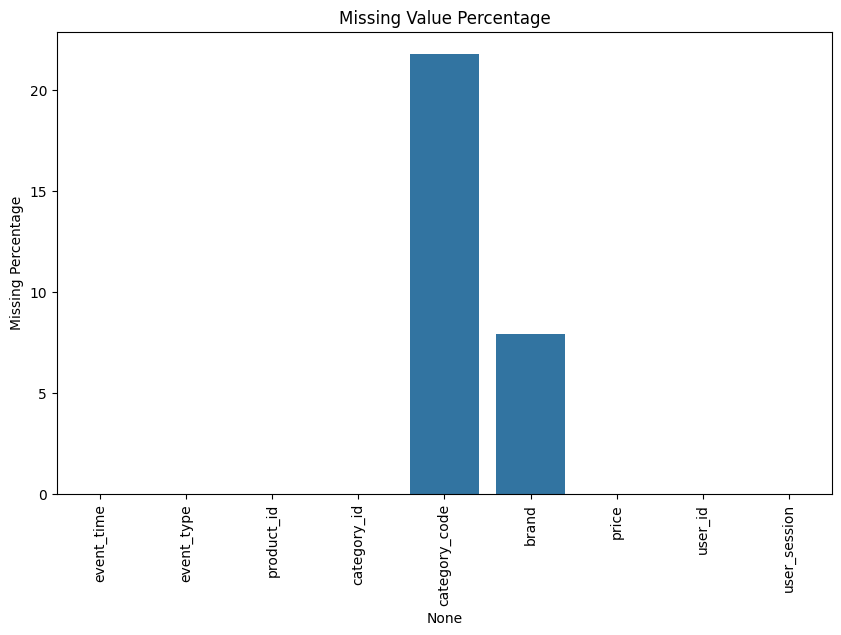

In [12]:
missing_values = df_muestra.isnull().sum()

missing_percentage = (df_muestra.isnull().sum() / len(df_muestra)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

print(missing_df.sort_values(by='Missing Percentage', ascending=False))

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(
    x=missing_df.index,
    y=missing_df['Missing Percentage']
)
plt.xticks(rotation=90)
plt.title("Missing Value Percentage")
plt.show()